<a href="https://colab.research.google.com/github/gorodnichenko16-cell/-/blob/main/%D0%94%D0%97_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [52]:
# генерация данных
SEQ_LEN = 10
N_SAMPLES = 10000

def make_pair(seq_len=SEQ_LEN):
    x = [random.randint(0, 9) for _ in range(seq_len)]
    y = [x[0]]
    for i in range(1, seq_len):
        y.append((x[i] + x[0]) % 10)
    return x, y

class NumDataset(Dataset):
    def __init__(self, n_samples):
        self.data = [make_pair() for _ in range(n_samples)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

train_ds = NumDataset(8000)
val_ds = NumDataset(2000)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

In [53]:
# модели
class SeqModel(nn.Module):
    def __init__(self, cell_type="rnn", vocab_size=10, emb_dim=16, hidden_dim=32):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        if cell_type == "rnn":
            self.cell = nn.RNNCell(emb_dim, hidden_dim)
        elif cell_type == "lstm":
            self.cell = nn.LSTMCell(emb_dim, hidden_dim)
        elif cell_type == "gru":
            self.cell = nn.GRUCell(emb_dim, hidden_dim)
        else:
            raise ValueError("cell_type must be rnn, lstm, or gru")
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.cell_type = cell_type
        self.hidden_dim = hidden_dim

    def forward(self, x):
        B, T = x.size()
        emb = self.emb(x)
        outputs = []

        if self.cell_type == "lstm":
            h = torch.zeros(B, self.hidden_dim, device=x.device)
            c = torch.zeros(B, self.hidden_dim, device=x.device)
            for t in range(T):
                h, c = self.cell(emb[:, t, :], (h, c))
                outputs.append(self.fc(h).unsqueeze(1))
        else:
            h = torch.zeros(B, self.hidden_dim, device=x.device)
            for t in range(T):
                h = self.cell(emb[:, t, :], h)
                outputs.append(self.fc(h).unsqueeze(1))

        return torch.cat(outputs, dim=1)

In [54]:
# обучение и проверка
def train_model(model, train_loader, val_loader, epochs=5):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for x, y in tqdm(train_loader, leave=False):
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = criterion(out.reshape(-1, 10), y.reshape(-1))
            loss.backward()
            opt.step()
            total_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x).argmax(-1)
                correct += (out == y).sum().item()
                total += y.numel()

        train_loss = total_loss / len(train_loader)
        val_acc = correct / total
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch}: loss={train_loss:.4f}, val_acc={val_acc:.4f}")

    return history

In [55]:
# запуск моделей
hist_rnn = train_model(SeqModel("rnn"), train_loader, val_loader, epochs=5)
hist_lstm = train_model(SeqModel("lstm"), train_loader, val_loader, epochs=5)
hist_gru = train_model(SeqModel("gru"), train_loader, val_loader, epochs=5)

Epoch 1: loss=2.2828, val_acc=0.1913


Epoch 2: loss=2.2387, val_acc=0.1928


Epoch 3: loss=2.1123, val_acc=0.2228


Epoch 4: loss=2.0057, val_acc=0.2519


Epoch 5: loss=1.9431, val_acc=0.2578


...

Epoch 1: loss=2.2836, val_acc=0.1918


Epoch 2: loss=2.2365, val_acc=0.2115


Epoch 3: loss=2.0703, val_acc=0.2978


Epoch 4: loss=1.7369, val_acc=0.4616


Epoch 5: loss=1.3373, val_acc=0.6645


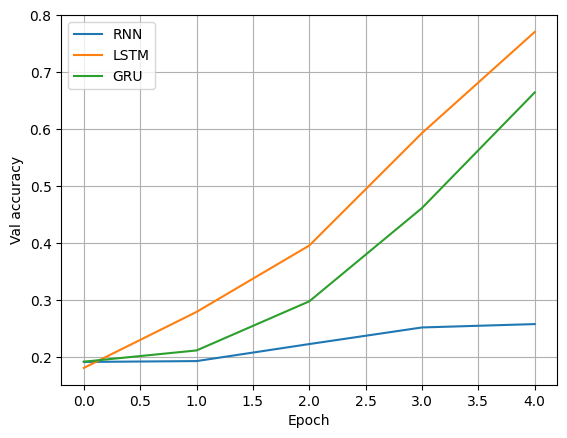

In [56]:
# сравнение моделей
import matplotlib.pyplot as plt

plt.plot(hist_rnn["val_acc"], label="RNN")
plt.plot(hist_lstm["val_acc"], label="LSTM")
plt.plot(hist_gru["val_acc"], label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Val accuracy")
plt.legend()
plt.grid(True)
plt.show()